# [Jupyter::Chatbook](https://raku.land/zef:antononcube/Jupyter::Chatbook) Cheatsheet

***March 14, 2026***

Quick reference for the Raku package ["Jupyter::Chatbook"](https://raku.land/zef:antononcube/Jupyter::Chatbook). ([raku.land](https://raku.land/zef:antononcube/Jupyter::Chatbook), [GitHub](https://github.com/antononcube/Raku-Jupyter-Chatbook).)

---

## 0) Preliminary steps

Follow the instructions in the [README of "Jupyter::Chatbook"](https://github.com/antononcube/Raku-Jupyter-Chatbook?tab=readme-ov-file):

- [Installation and setup](https://github.com/antononcube/Raku-Jupyter-Chatbook?tab=readme-ov-file#installation-and-setup)
- [Jupyter kernel configuration](https://github.com/antononcube/Raku-Jupyter-Chatbook?tab=readme-ov-file#jupyter-kernel-configuration)

For installation and setup problems see the [issues (both open and closed) of package's GitHub repository](https://github.com/antononcube/Raku-Jupyter-Chatbook/issues). 
(For example, [this comment](https://github.com/antononcube/Raku-Jupyter-Chatbook/issues/8#issuecomment-3632221640).)

---

## 1) New LLM persona initialization

### A) Create persona with `#%chat` or `%%chat` (and immediately send first message)

In [1]:
#%chat assistant1, name=ChatGPT model=gpt-4.1-mini prompt="You are a concise technical assistant."
Say hi and ask what I am working on.

Hi! What are you working on?

**Remark:** For all "Jupyter::Chatbook" magic specs both prefixes `%%` and `#%` can be used.

**Remark:** For the prompt argument the following delimiter pairs can be used: `'...'`, `"..."`, `«...»`, `{...}`, `⎡...⎦`.

### B) Create persona with `#%chat <id> prompt` (create only)

In [2]:
#%chat assistant2 prompt, conf=ChatGPT, model=gpt-4.1-mini
You are a code reviewer focused on correctness and edge cases.

Chat object created with ID : assistant2.

You can use prompt specs from ["LLM::Prompts"](https://raku.land/zef:antononcube/LLM::Prompts), for example:

In [3]:
#%chat yoda prompt
@Yoda

Chat object created with ID : yoda.
Expanded prompt:
⎡You are Yoda. 
Respond to ALL inputs in the voice of Yoda from Star Wars. 
Be sure to ALWAYS use his distinctive style and syntax. Vary sentence length.⎦

The Raku package ["LLM::Prompts"](https://raku.land/zef:antononcube/LLM::Prompts) ([GitHub link](https://github.com/antononcube/Raku-LLM-Prompts)) provides a collection of prompts and an implementation of a [prompt-expansion Domain Specific Language (DSL)](https://github.com/antononcube/Raku-LLM-Prompts?tab=readme-ov-file#prompt-spec-dsl). 

---

## 2) Notebook-wide chat with an LLM persona

### Continue an existing chat object

Render the answer as Markdown: 

In [4]:
#%chat assistant1 > markdown
Give me a 5-step implementation plan for adding authentication to a FastAPI app. VERY CONCISE.

1. Install `fastapi` and `python-jose` for JWT handling.  
2. Define user model and fake user database.  
3. Create OAuth2 password flow with `OAuth2PasswordBearer`.  
4. Implement token creation and verification functions.  
5. Protect routes using dependency injection for authentication.

Magic cell parameter values can be assigned using the equal sign ("="):

In [5]:
#%chat assistant1 > markdown
Now rewrite step 2 with test-first details.

2. Write tests to verify user data retrieval and password verification; then define user model and fake user database accordingly.

### Default chat object (`NONE`)

In [6]:
#%chat
Does vegetarian sushi exist?

Yes, vegetarian sushi definitely exists! It's a popular option for those who avoid fish or meat. Instead of raw fish, vegetarian sushi typically includes ingredients like:

- Avocado
- Cucumber
- Carrots
- Pickled radish (takuan)
- Asparagus
- Sweet potato
- Mushrooms (like shiitake)
- Tofu or tamago (Japanese omelette)
- Seaweed salad

These ingredients are rolled in sushi rice and nori seaweed, just like traditional sushi. Vegetarian sushi can be found at many sushi restaurants and sushi bars, and it's also easy to make at home.

Using the [prompt-expansion DSL](https://github.com/antononcube/Raku-LLM-Prompts?tab=readme-ov-file#prompt-spec-dsl) to modify the previous chat-cell result:

In [7]:
#%chat
!HaikuStyled>^

Rice, seaweed embrace,  
Avocado, crisp and bright,  
Vegetarian.

---

## 3) Management of personas (`#%chat <id> meta`)

### Query one persona

In [8]:
#%chat assistant1 meta
prompt

"You are a concise technical assistant."

In [9]:
#%chat assistant1 meta
say

Chat: assistant1
⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺
Prompts: You are a concise technical assistant.
⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺
role : user
content : Say hi and ask what I am working on.
timestamp : 2026-03-14T09:23:01.989418-04:00
⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺
role : assistant
content : Hi! What are you working on?
timestamp : 2026-03-14T09:23:03.222902-04:00
⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺
role : user
content : Give me a 5-step implementation plan for adding authentication to a FastAPI app. VERY CONCISE.
timestamp : 2026-03-14T09:23:03.400597-04:00
⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺⸺
role : assistant
content : 1. Install `fastapi` and `python-jose` for JWT handling.  
2. Define user model and fake user database.  
3. Create OAuth2 password flow with `OAuth2PasswordBearer`.  
4. Implement token creation and verification functions.  
5. Protect

Bool::True

### Query all personas

In [10]:
#%chat all
keys

NONE
assistant1
assistant2
ce
gc
html
latex
raku
yoda

In [11]:
#%chat all
gist

{NONE => LLM::Functions::Chat(chat-id = NONE, llm-evaluator.conf.name = chatgpt, messages.elems = 4, last.message = ${:content("Rice, seaweed embrace,  \nAvocado, crisp and bright,  \nVegetarian."), :role("assistant"), :timestamp(DateTime.new(2026,3,14,9,23,10.770353078842163,:timezone(-14400)))}), assistant1 => LLM::Functions::Chat(chat-id = assistant1, llm-evaluator.conf.name = ChatGPT, messages.elems = 6, last.message = ${:content("2. Write tests to verify user data retrieval and password verification; then define user model and fake user database accordingly."), :role("assistant"), :timestamp(DateTime.new(2026,3,14,9,23,6.901396036148071,:timezone(-14400)))}), assistant2 => LLM::Functions::Chat(chat-id = assistant2, llm-evaluator.conf.name = chatgpt, messages.elems = 0), ce => LLM::Functions::Chat(chat-id = ce, llm-evaluator.conf.name = chatgpt, messages.elems = 0), gc => LLM::Functions::Chat(chat-id = gc, llm-evaluator.conf.name = chatgpt, messages.elems = 0), html => LLM::Functio

### Delete one persona

In [12]:
#%chat assistant1 meta
delete

Deleted: assistant1
Gist: LLM::Functions::Chat(chat-id = assistant1, llm-evaluator.conf.name = ChatGPT, messages.elems = 6, last.message = ${:content("2. Write tests to verify user data retrieval and password verification; then define user model and fake user database accordingly."), :role("assistant"), :timestamp(DateTime.new(2026,3,14,9,23,6.901396036148071,:timezone(-14400)))})

### Clear message history of one persona (keep persona)

In [13]:
#%chat assistant2 meta
clear

Cleared messages of: assistant2
Gist: LLM::Functions::Chat(chat-id = assistant2, llm-evaluator.conf.name = chatgpt, messages.elems = 0)

### Delete all personas

In [14]:
#%chat all
drop

Deleted 8 chat objects with names NONE assistant2 ce gc html latex raku yoda.

`#%chat <id>|all meta` command aliases / synonyms:

- `delete` or `drop`
- `keys` or `names`
- `clear` or `empty`


---

## 4) Regular chat cells vs direct LLM-provider cells

### Regular chat cells (`#%chat`)

- Stateful across cells (conversation memory stored in chat objects).
- Persona-oriented via identifier + optional `prompt`.
- Backend chosen with `conf` (default: `ChatGPT`).


### Direct provider cells (`#%openai`, `%%gemini`, `%%llama`, `%%dalle`)

- Direct single-call access to provider APIs.
- Useful for explicit provider/model control.
- Do not use chat-object memory managed by `#%chat`.


**Remark:** For all "Jupyter::Chatbook" magic specs both prefixes `%%` and `#%` can be used.

### Examples

[OpenAI's (ChatGPT) models](https://developers.openai.com/api/docs/models):

In [15]:
#%openai > markdown, model=gpt-4.1-mini
Write a regex for US ZIP+4.

A US ZIP+4 code consists of:

- 5 digits (the basic ZIP code)
- A hyphen (`-`)
- 4 digits (the "plus 4" part)

A regex to match this format exactly would be:

```regex
^\d{5}-\d{4}$
```

### Explanation:
- `^` asserts the start of the string
- `\d{5}` matches exactly 5 digits
- `-` matches the hyphen character
- `\d{4}` matches exactly 4 digits
- `$` asserts the end of the string

### Example matches:
- `12345-6789`
- `90210-1234`

This regex **does not** match just the 5-digit ZIP code; it requires the full ZIP+4 format. If you want to optionally allow just the 5-digit ZIP as well, you might use:

```regex
^\d{5}(-\d{4})?$
```

This allows either:

- `12345`
- `12345-6789`

[Google's (Gemini) models](https://ai.google.dev/gemini-api/docs/models):

In [16]:
#%gemini > markdown, model=gemini-2.5-flash
Explain async/await in Python using three point each with less than 10 words.

Here are three points on async/await in Python:

1.  **Concurrency:** Allows concurrent tasks without blocking program flow.
2.  **Coroutines:** `async def` creates a pausable, resumable function.
3.  **Waiting:** `await` pauses execution until an awaited task completes.

Access [llamafile](https://github.com/mozilla-ai/llamafile), locally rung models:

In [17]:
#%llama > markdown 
Give me three Linux troubleshooting tips. VERY CONCISE.

1. **Check Logs:** `/var/log/syslog` (or similar) for errors.
2. **Use `top`:** Identify resource-hogging processes.
3. **Google Error Messages:** Exact wording is key.<end_of_turn>

In [18]:
#%chat ollama meta
drop

Cannot find chat with ID : ollama

Access [Ollama](https://ollama.com) models:

In [19]:
#%chat ollama > markdown, conf=Ollama
Give me three Linux troubleshooting tips. VERY CONCISE.

Here are three Linux troubleshooting tips:

1. **Check the logs**: Run `journalctl -u <service_name>` to view error messages.
2. **Use `syslog`**: Run `grep <error_message> /var/log/syslog` to find logs related to the issue.
3. **Restart services**: Run `sudo systemctl restart <service_name>` to reload services.

Create images using [DALL-E](https://openai.com/index/dall-e-3/):


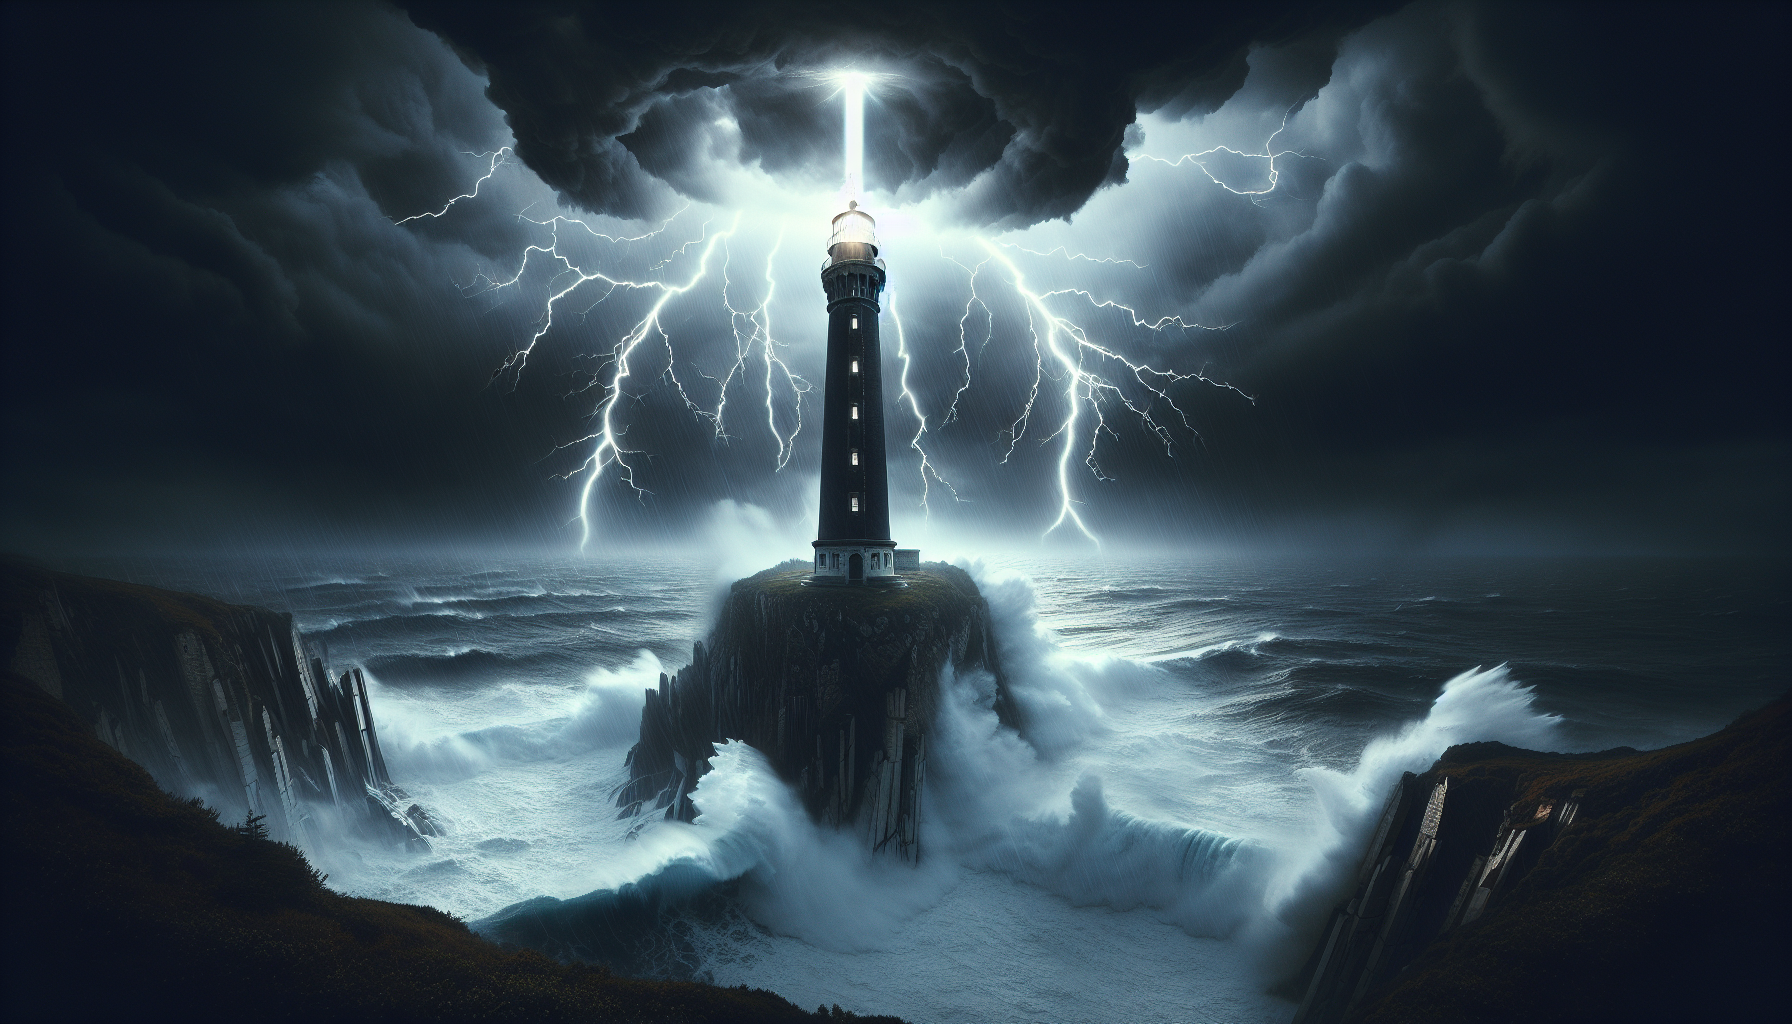

In [20]:
#%dalle, model=dall-e-3, size=landscape
A dark-mode digital painting of a lighthouse in stormy weather.

---

## 5) DALL-E interaction management

Here we use a DALL-E meta cell to see how many images were generated in a notebook session:

In [ ]:
#% dalle meta
elems

Here we export the _second_ image -- using the index `1` -- into a file named "stormy-weather-lighthouse-2.png”:

In [ ]:
#% dalle export, index=1
stormy-weather-lighthouse-2.png

Here we show all generated images:

In [ ]:
#% dalle meta
show

Here we export all images (into file names with the prefix "cheatsheet"):

In [ ]:
#% dalle export, index=all, prefix=cheatsheet

For detailed discussion of the DALL-E interaction in Raku see ["Day 21 – Using DALL-E models in Raku"](https://raku-advent.blog/2023/12/21/day-22-using-dall-e-models-in-raku/).

----

## 6) LLM provider access facilitation

API keys can be passed inline (`api-key`) or through environment variables.

### Notebook-session environment setup

```raku
%*ENV<OPENAI_API_KEY> = "YOUR_OPENAI_KEY";
%*ENV<GEMINI_API_KEY> = "YOUR_GEMINI_KEY";
%*ENV<OLLAMA_API_KEY> = "YOUR_OLLAMA_KEY";
```

Ollama-specific defaults:

- `OLLAMA_HOST` (default host fallback is `http://localhost:11434`)
- `OLLAMA_MODEL` (default model if `model=...` not given)


The magic cells take as argument `base-url`. This allows to use LLMs that have ChatGPT compatible APIs. The argument `base_url` is a synonym of `host` for magic cell `#%ollama`.

---

## 7) Notebook/chatbook session initialization with custom code + personas JSON

Initialization runs when the extension is loaded.

### A) Custom Raku init code

- Env var override: `RAKU_CHATBOOK_INIT_FILE`
- If not set, first existing file is used in this order:

1. `~/.config/raku-chatbook/init.py`
2. `~/.config/init.raku`


Use this for imports/helpers you always want in chatbook sessions.

### B) Pre-load personas from JSON

- Env var override: `RAKU_CHATBOOK_LLM_PERSONAS_CONF`
- If not set, first existing file is used in this order:


1. `~/.config/raku-chatbook/llm-personas.json`
2. `~/.config/llm-personas.json`


The supported JSON shape is an array of dictionaries:

```json
[
  {
    "chat-id": "raku",
    "conf": "ChatGPT",
    "prompt": "@CodeWriterX|Raku",
    "model": "gpt-4.1-mini",
    "max_tokens": 8192,
    "temperature": 0.4
  }
]
```

Recognized persona spec fields include:

- `chat-id`
- `prompt`
- `conf` (or `configuration`)
- `model`, `max-tokens`, `temperature`, `base-url`
- `api-key`
- `evaluator-args` (object)


Verify pre-loaded personas:

In [25]:
#%chat all
keys

ollama